# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [2]:
import pandas as pd
rainfall = pd.read_csv("data/snotel_rainfall_data.csv")

#print(rainfall.head())
rainfall.describe()

,Date,Precip_in
count,61,58
unique,60,32
top,2024-01-16,0.0
freq,2,27


## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [3]:
rainfall['Precip_in'] = pd.to_numeric(rainfall['Precip_in'], errors='coerce')
rainfall.describe()

,Precip_in
count,56.000000
mean,-8.467089
std,150.395286
min,-999.000000
25%,0.000000
50%,0.050563
75%,0.682890
max,500.000000


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [4]:
streamflow_cfs = pd.read_csv("data/streamflow_data.csv")
#streamflow_cfs.head()
#streamflow_cfs.describe()

streamflow_cfs['Streamflow_cfs'] = pd.to_numeric(streamflow_cfs['Streamflow_cfs'], errors='coerce')
streamflow_cfs.describe()

,Streamflow_cfs
count,54.000000
mean,40.058333
std,369.096212
min,-999.000000
25%,10.100000
50%,10.600000
75%,13.900000
max,2510.000000


## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [5]:
#streamflow
stream_drop = streamflow_cfs
stream_drop['Streamflow_cfs'] = stream_drop['Streamflow_cfs'].drop(stream_drop['Streamflow_cfs'].idxmin())
stream_drop = stream_drop.dropna(subset=['Streamflow_cfs'])


stream_fill = streamflow_cfs 
stream_fill['Streamflow_cfs'] = stream_fill['Streamflow_cfs'].fillna(stream_fill['Streamflow_cfs'].mean())


stream_int = streamflow_cfs
stream_int['Streamflow_cfs'] = stream_int['Streamflow_cfs'].interpolate(method = 'linear')


#rainfall
rain_drop = rainfall
rain_drop['Precip_in'] = rain_drop['Precip_in'].drop(rain_drop['Precip_in'].idxmin())
rain_drop = rain_drop.dropna(subset=['Precip_in']) 

rain_fill = rainfall 
rain_fill['Precip_in'] = rain_fill['Precip_in'].fillna(rain_fill['Precip_in'].mean())


rain_int = rainfall
rain_int['Precip_in'] = rain_int['Precip_in'].interpolate(method = 'linear')

## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [41]:
key=["drop","fill","int"]
rainfall_methods = pd.concat([rain_drop, rain_fill, rain_int],keys=key)
#print(rainfall_methods.loc[("fill")])

streamflow_methods = pd.concat([stream_drop,stream_fill,stream_int],keys=key)


## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

<Axes: title={'center': 'Streamflow Dataframe'}, xlabel='Date'>

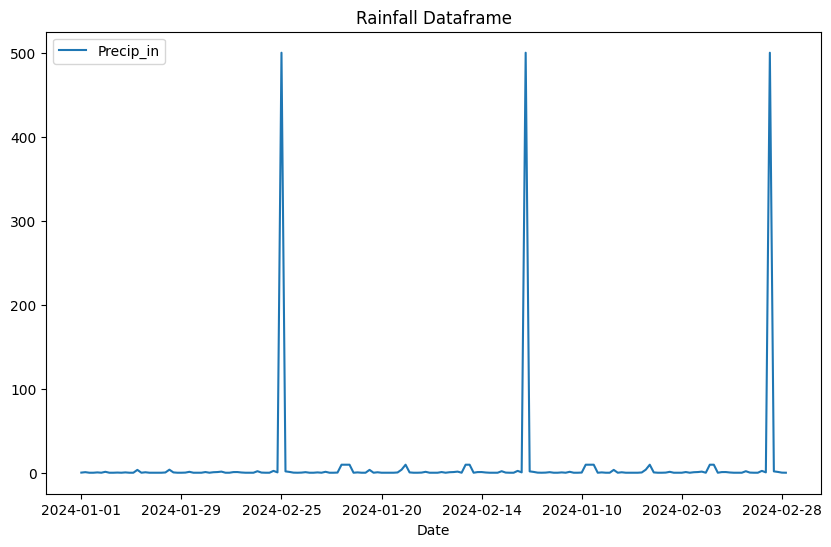

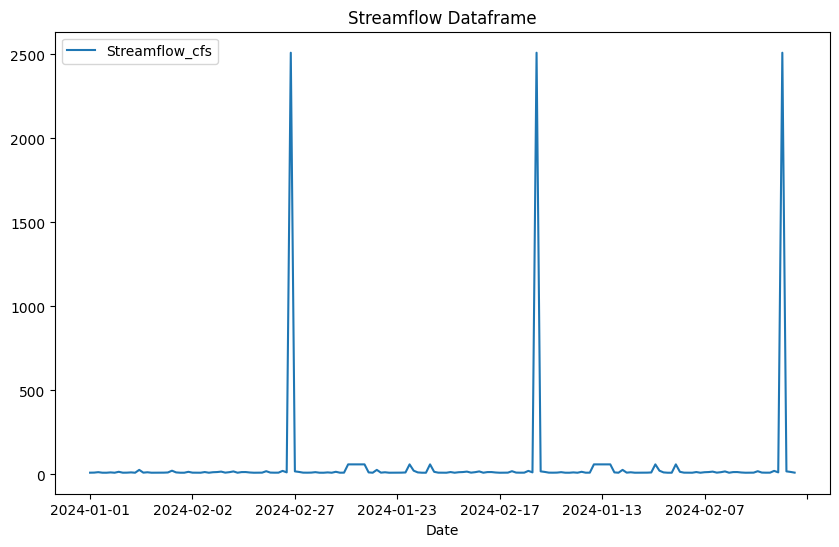

In [39]:
rainfall_methods.plot(kind='line',x="Date",y="Precip_in",figsize=(10,6),title="Rainfall Dataframe",)
#rainfall_methods.loc[('drop')].plot(figsize=(10,6),x="Date")
streamflow_methods.plot(kind='line',x="Date",y="Streamflow_cfs",figsize=(10,6),title="Streamflow Dataframe",)

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

In [ ]:
rain_flow_df = pd.merge(rainfall_methods.loc[('drop')],streamflow_methods.loc[('drop')])

          Date   Precip_in  Streamflow_cfs
0   2024-01-01    0.140280           10.25
1   2024-01-02    0.659018           10.70
2   2024-01-03    0.000000           13.30
3   2024-01-04    0.000000           10.10
4   2024-01-05    0.375729           10.00
5   2024-01-06    0.000000           11.90
6   2024-01-07    1.095458           10.00
7   2024-01-08    0.000000           15.50
8   2024-01-09    0.000000           10.15
9   2024-01-10    0.186576           10.45
10  2024-01-16    0.000000           11.95
11  2024-01-16    0.000000           11.95
12  2024-01-17    3.380971           10.00
13  2024-01-18    0.000000           26.90
14  2024-01-19    0.532611           10.45
15  2024-01-20    0.000000           12.65
16  2024-01-21    0.000000           10.05
17  2024-01-22    0.000000           10.00
18  2024-01-23    0.000000           10.35
19  2024-01-24    0.301443           10.50
20  2024-01-25    3.609354           11.50
21  2024-01-27    0.370825           22.10
22  2024-01

## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [76]:
import datetime as dt
rain_flow_df['Date'] = pd.to_datetime(rain_flow_df['Date'])
#print(rain_flow_df['Date'].dt.month)

jan = rain_flow_df[rain_flow_df['Date'].dt.month == 1].index
feb = rain_flow_df[rain_flow_df['Date'].dt.month == 2].index

print("January: ", rain_flow_df[jan[0]:jan[-1]].describe(),'\n', sep='\n')
print("February: ", rain_flow_df[feb[0]:feb[-1]].describe(), sep='\n')


January: 
                      Date  Precip_in  Streamflow_cfs     1
count                   24  24.000000        24.00000  24.0
mean   2024-01-15 00:00:00   0.443844        12.19375   1.0
min    2024-01-01 00:00:00   0.000000        10.00000   1.0
25%    2024-01-06 18:00:00   0.000000        10.08750   1.0
50%    2024-01-16 12:00:00   0.000000        10.47500   1.0
75%    2024-01-22 06:00:00   0.372051        11.95000   1.0
max    2024-01-29 00:00:00   3.609354        26.90000   1.0
std                    NaN   0.979629         4.08037   0.0


February: 
                                Date   Precip_in  Streamflow_cfs     1
count                             26   26.000000       26.000000  26.0
mean   2024-02-14 19:23:04.615384576   19.714663      109.123077   2.0
min              2024-02-01 00:00:00    0.000000       10.000000   2.0
25%              2024-02-07 06:00:00    0.000000       10.287500   2.0
50%              2024-02-15 12:00:00    0.221111       12.550000   2.0
75%        

## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

In [77]:
rain_flow_SI_df = rain_flow_df
rain_flow_df["Precip_in"] = rain_flow_df["Precip_in"] * 25.4
rain_flow_df["Streamflow_cfs"] = rain_flow_df["Streamflow_cfs"] * .028


## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?